In [1]:
import os, sys
import pickle

import matplotlib_inline
sys.path.append("../")

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
from matplotlib import gridspec
from matplotlib import ticker
from matplotlib.lines import Line2D

from tqdm import tqdm

from scipy.interpolate import interp1d
import numpy as np
import pymaster as nmt

matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

%matplotlib inline
%load_ext autoreload
%autoreload 2
# Load plot settings
import healpy as hp
from plot_params import params
pylab.rcParams.update(params)

cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [2]:
# load power spectra
binning = nmt.NmtBin.from_nside_linear(2048, 10)

mccarthy_Cls = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/Planck_maps/clean_auto_Cls_binning10.npy")
mock_planck_Cls = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_Planck/clean_auto_Cls_binning10.npy")
small_beam = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_planck_small_beam/clean_auto_Cls_binning10.npy")
radio_big_pt_src = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_100mJy/clean_auto_Cls_binning10.npy")
actual_radio = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src/clean_auto_Cls_binning10.npy")
new_freq = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_0.1mJy_new_freq/clean_auto_Cls_binning10.npy")
new_freq_big_pt_src = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_100mJy_new_freq/clean_auto_Cls_binning10.npy")

signal = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/halo_data/correct_virial_mass/Cl_PP_mA5.623e-13.npy")
signal_ls = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/halo_data/correct_virial_mass/ls.npy")

In [3]:
mccarthy_covs = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/Planck_maps/covariance_clean_PP_binning10_K22.npy")
mock_planck_covs = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_Planck/covariance_clean_PP_binning10_K22.npy")
actual_radio_covs = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src/covariance_clean_PP_binning10_K22.npy")
radio_big_pt_src_covs = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_100mJy/covariance_clean_PP_binning10_K22.npy")
small_beam_covs = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_planck_small_beam/covariance_clean_PP_binning10_K22.npy")
new_freq_covs = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_0.1mJy_new_freq/covariance_clean_PP_binning10_K22.npy")
new_freq_big_pt_src_covs = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_100mJy_new_freq/covariance_clean_PP_binning10_K22.npy")

In [4]:
TCMB_eV = 0.000235264 
x = 2 * np.pi * 0.000232349 /TCMB_eV #353 * 2pi
mc_prefac = TCMB_eV * x**2 / (1- np.exp(-x))
epsilon = 3e-7
# epsilon_us  

In [5]:
new_prefac = 2* np.pi * 410e6 * 6.58212e-16 # convert MHz to eV
# changes normalization to be at radio frequency

In [6]:
# load power spectra
cross_binning = nmt.NmtBin.from_nside_linear(2048, 150)

mccarthy_cross_Cls = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/Planck_maps/cross_Pg_Cls_binning150_K22.npy")
mock_planck_cross_Cls = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_Planck/cross_Pg_Cls_binning150_K22.npy")
small_beam_cross = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_planck_small_beam/cross_Pg_Cls_binning150_K22.npy")
radio_big_pt_src_cross = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_100mJy/cross_Pg_Cls_binning150_K22.npy")
actual_radio_cross = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src/cross_Pg_Cls_binning150_K22.npy")
new_freq_cross = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_0.1mJy_new_freq/cross_Pg_Cls_binning150_K22.npy")
cross_signal = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/halo_data/correct_virial_mass/Cl_gP_mA5.623e-13_modelK22.npy")

In [7]:
mccarthy_cross_covs = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/Planck_maps/covariance_clean_gP_binning150_K22.npy")
mock_planck_cross_covs = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_Planck/covariance_clean_gP_binning150_K22.npy")
actual_radio_cross_covs = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src/covariance_clean_gP_binning150_K22.npy")
radio_big_pt_src_cross_covs = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_100mJy/covariance_clean_gP_binning150_K22.npy")
small_beam_cross_covs = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_planck_small_beam/covariance_clean_gP_binning150_K22.npy")
new_freq_cross_covs = np.load('/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_alt_pt_src_0.1mJy_new_freq/covariance_clean_gP_binning150_K22.npy')

In [9]:
new_Cls = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_pt_src_test/clean_auto_Cls_binning10.npy")

In [10]:
new_Cls

array([ 1.05801735e-11, -1.63824699e-12,  2.75824490e-13, -5.10246416e-14,
        7.24356020e-15,  8.96403557e-17,  4.02461757e-17, -5.01969708e-16,
       -4.74036187e-16,  1.97854826e-16, -1.75054276e-16,  4.77750270e-16,
        2.82907006e-16,  1.55182321e-16,  4.91403961e-16,  3.07040218e-16,
        3.79624062e-16,  4.29055281e-16,  2.22192044e-16,  3.19327721e-16,
        3.17345786e-16,  3.43614002e-16,  1.79433839e-16,  2.39496608e-16,
        2.11945117e-16,  1.84977562e-16,  2.20029950e-16,  1.35352684e-16,
        1.46622617e-16,  1.06223483e-16,  1.58955206e-16,  9.91711156e-17,
        1.11103596e-16,  8.45225125e-17,  1.18533921e-16,  7.90522068e-17,
        6.32781055e-17,  6.82648488e-17,  7.26965226e-17,  4.06625223e-17,
        5.90218382e-17,  5.10936624e-17,  3.95466288e-17,  6.19030402e-17,
        5.55464817e-17,  5.12825883e-17,  4.82099653e-17,  5.65228404e-17,
        4.27627278e-17,  4.65937645e-17,  4.64528259e-17,  4.82402779e-17,
        3.86570605e-17,  

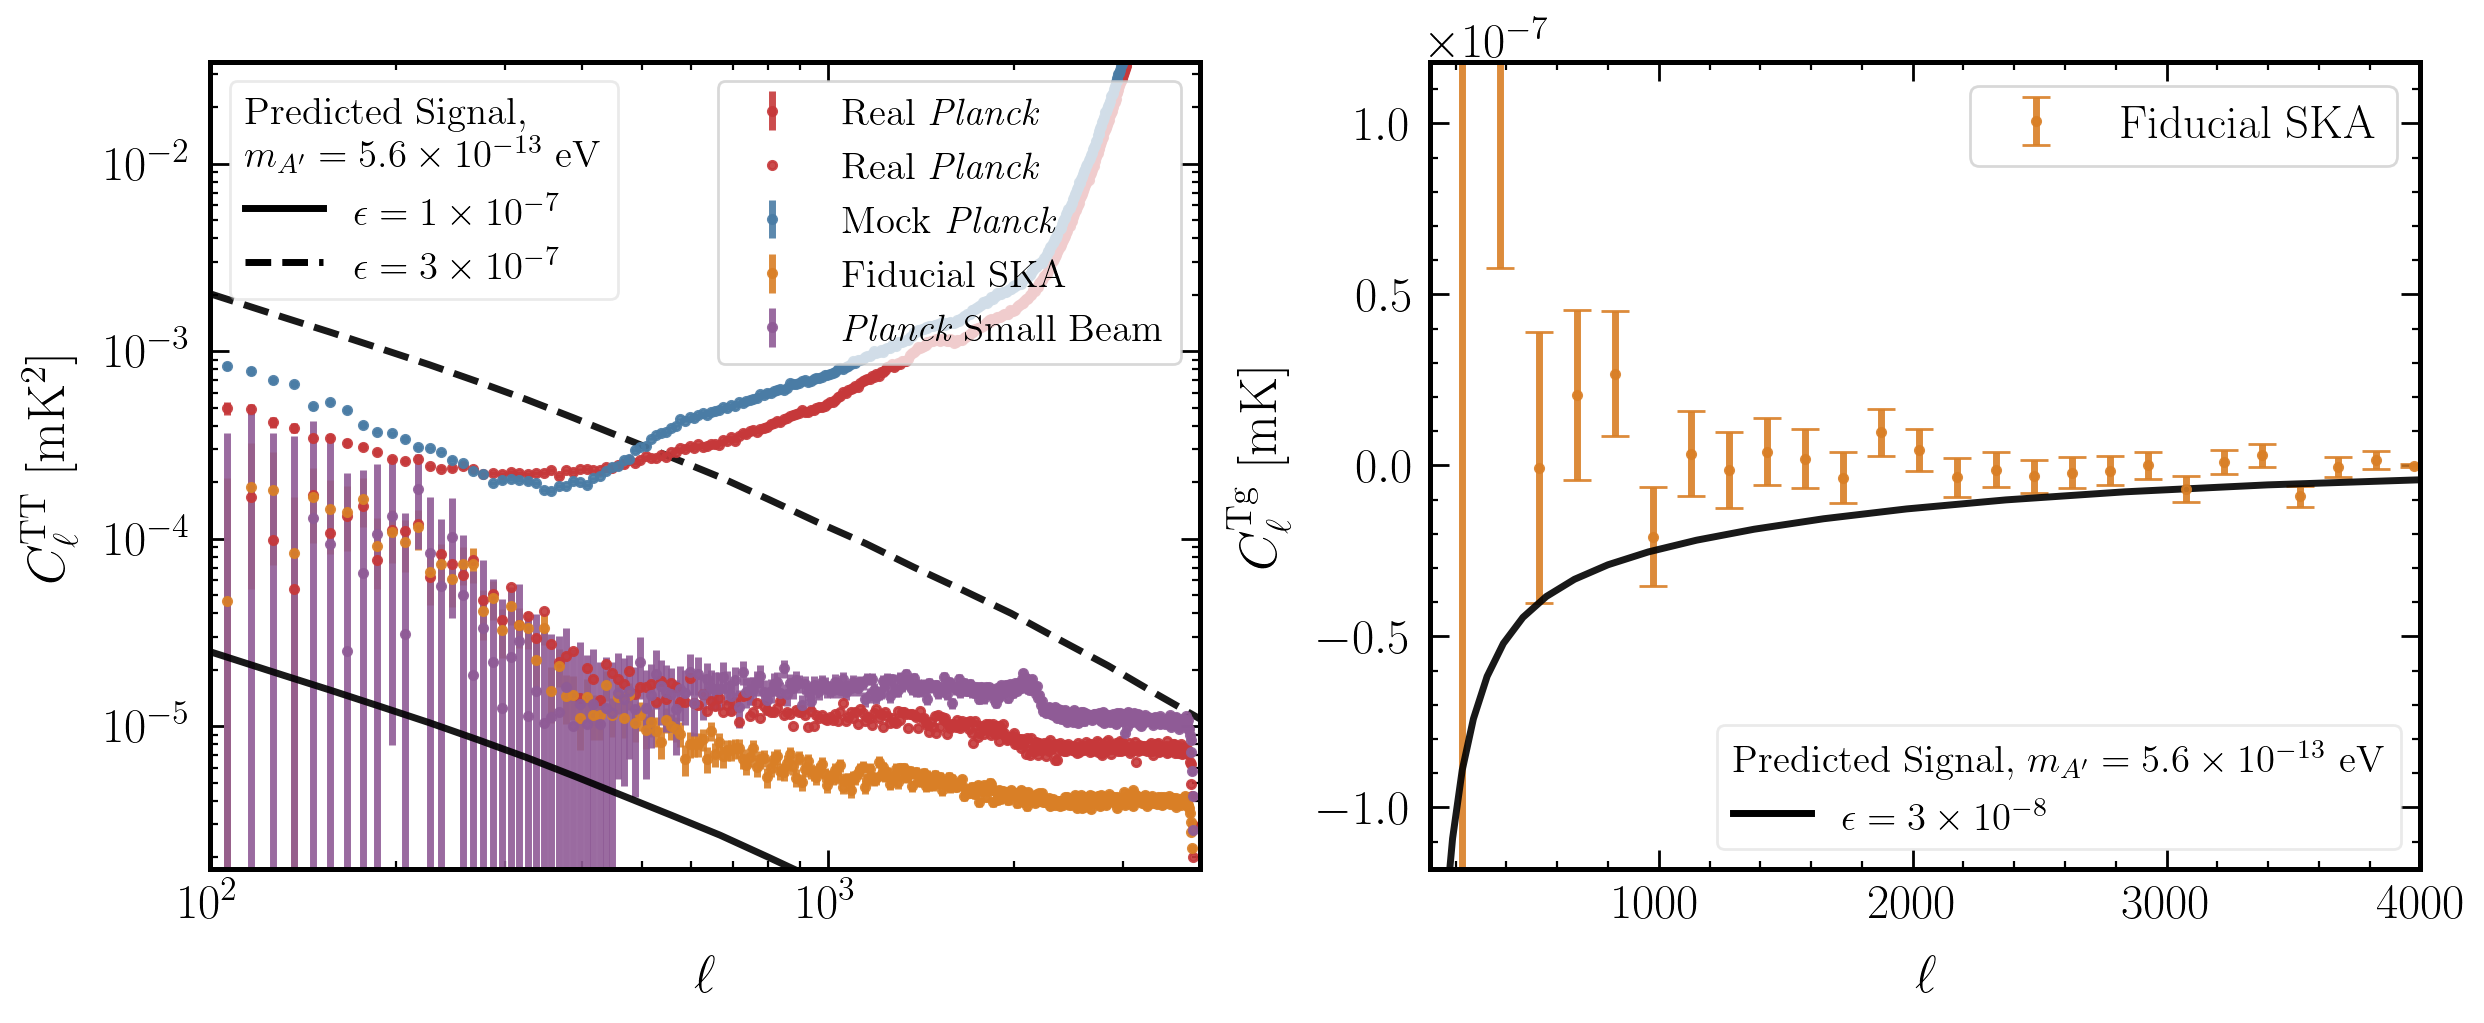

In [12]:
from matplotlib.lines import lineStyles

fig, ax = plt.subplots(1, 2, figsize=(2*6.153846153846153, 5.0), constrained_layout=True)


ax[0].errorbar(
    binning.get_effective_ells(),
    mccarthy_Cls * mc_prefac**2 / new_prefac**2 ,
    yerr=mc_prefac**2 * np.sqrt(np.diag(mccarthy_covs)) / new_prefac**2,
    capsize=0,
    linestyle=" ",
    marker=".",
    label=r"Real \textit{Planck}",
    color=cols_default[0],
)
ax[0].errorbar(
    nmt.NmtBin.from_nside_linear(2048, 10).get_effective_ells(),
    new_Cls / new_prefac**2 ,
    # yerr=mc_prefac**2 * np.sqrt(np.diag(mccarthy_covs)) / new_prefac**2,
    capsize=0,
    linestyle=" ",
    marker=".",
    label=r"Real \textit{Planck}",
    color=cols_default[0],
)
ax[0].errorbar(
    binning.get_effective_ells(),
    mock_planck_Cls * mc_prefac**2 / new_prefac**2,
    yerr= mc_prefac**2 * np.sqrt(np.diag(mock_planck_covs)) / new_prefac**2,
    capsize=0,
    linestyle=" ",
    marker=".",
    label=r"Mock \textit{Planck}",
    color=cols_default[1],
)

ax[0].errorbar(
    binning.get_effective_ells(),
    new_freq / new_prefac**2,
    yerr=np.sqrt(np.diag(new_freq_covs)) / new_prefac**2,
    capsize=0,
    linestyle=" ",
    marker=".",
    label="Fiducial SKA",
    color=cols_default[4],
)

# ax[0].errorbar(
#     binning.get_effective_ells(),
#     radio_big_pt_src / new_prefac**2,
#     yerr=np.sqrt(np.diag(radio_big_pt_src_covs)) / new_prefac**2,
#     capsize=0,
#     linestyle=" ",
#     marker=".",
#     label=r"SKA, $S_{\rm min}=100$ mJy",
#     color=cols_default[5],
# )
ax[0].errorbar(
    binning.get_effective_ells(),
    small_beam / new_prefac**2,
    yerr=np.sqrt(np.diag(small_beam_covs)) / new_prefac**2,
    capsize=0,
    linestyle=" ",
    marker=".",
    label=r"$\textit{Planck}$ Small Beam",
    color=cols_default[3],
)
ax[0].plot(
    signal_ls,
    (2.73e3) ** 2 * (1e-7)**4 * signal / new_prefac**2,
    linestyle="-",
    color="k",
    # label="Theoretical Signal",
)
ax[0].plot(
    signal_ls,
    (2.73e3) ** 2 * (3e-7)**4 * signal / new_prefac**2,
    linestyle="--",
    color="k",
    # label="Theoretical Signal",
)
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xlim(100, 4000)
ax[0].set_ylim(0.5e-17 / new_prefac**2, 1e-13 / new_prefac**2)

small_eps_line = Line2D([0,1],[0,1],linestyle='-', color='k')
big_eps_line = Line2D([0,1],[0,1],linestyle='--', color='k')
legend2 = ax[0].legend([small_eps_line, big_eps_line], [r"$\epsilon=1\times10^{-7}$", r"$\epsilon=3\times10^{-7}$"], 
                     fontsize=14, loc="upper left", frameon=True, 
                     title="Predicted Signal,\n" + r"$m_{A'}=5.6\times 10^{-13}$ eV",
                     title_fontsize=14)

# legend2.set_title("Predicted Signal,\n" + r"$m_{A'}=5.6\times 10^{-13}$ eV")
ax[0].add_artist(legend2)
legend2._legend_box.align = 'left'
    
legend1 = ax[0].legend(fontsize=14, frameon=True, loc="upper right", framealpha=0.75) # loc='center left', bbox_to_anchor=(1, 0.5))

ax[0].set_xlabel(r"$\ell$")
ax[0].set_ylabel(r"$C^{\rm TT}_\ell$ [mK$^2$]")


ax[1].errorbar(
    cross_binning.get_effective_ells(),
    new_freq_cross / new_prefac,
    yerr=np.sqrt(np.diag(new_freq_cross_covs)) / new_prefac,
    # capsize=0,
    linestyle=" ",
    marker=".",
    label="Fiducial SKA",
    color=cols_default[4],
)

ax[1].plot(
    signal_ls,
    -(2.73e3) * (3e-8)**2 * cross_signal /new_prefac,
    linestyle="-",
    color="k",
    # label="Theoretical Signal",
)

legend2 = ax[1].legend([small_eps_line], [r"$\epsilon=3\times 10^{-8}$"], 
                     loc="lower right", frameon=True, 
                     title=r"Predicted Signal, $m_{A'}=5.6\times 10^{-13}$ eV", 
                     title_fontsize=14, fontsize=14)

ax[1].add_artist(legend2)
legend2._legend_box.align = 'left'

legend1 = ax[1].legend(frameon=True, loc="upper right", framealpha=0.75) # loc='center left', bbox_to_anchor=(1, 0.5))

# ax[1].set_xscale("log")
ax[1].set_xlim(100, 4000)
ax[1].set_ylim(-0.2e-12/new_prefac,  0.2e-12/new_prefac)

ax[1].set_xlabel(r"$\ell$")
ax[1].set_ylabel(r"$C^{\rm Tg}_\ell$ [mK]")
ax[1].ticklabel_format(axis='y', style='sci', scilimits=(-4, 4))
# plt.savefig("plots/Cl_comparsion.pdf", bbox_inches="tight")

# plt.xlabel(r"$\ell$")
# plt.ylabel(r"$C^{\rm TT}_\ell$ [mK$^2$]")
# plt.savefig("plots/mccarthy_comparison.pdf", bbox_inches="tight")

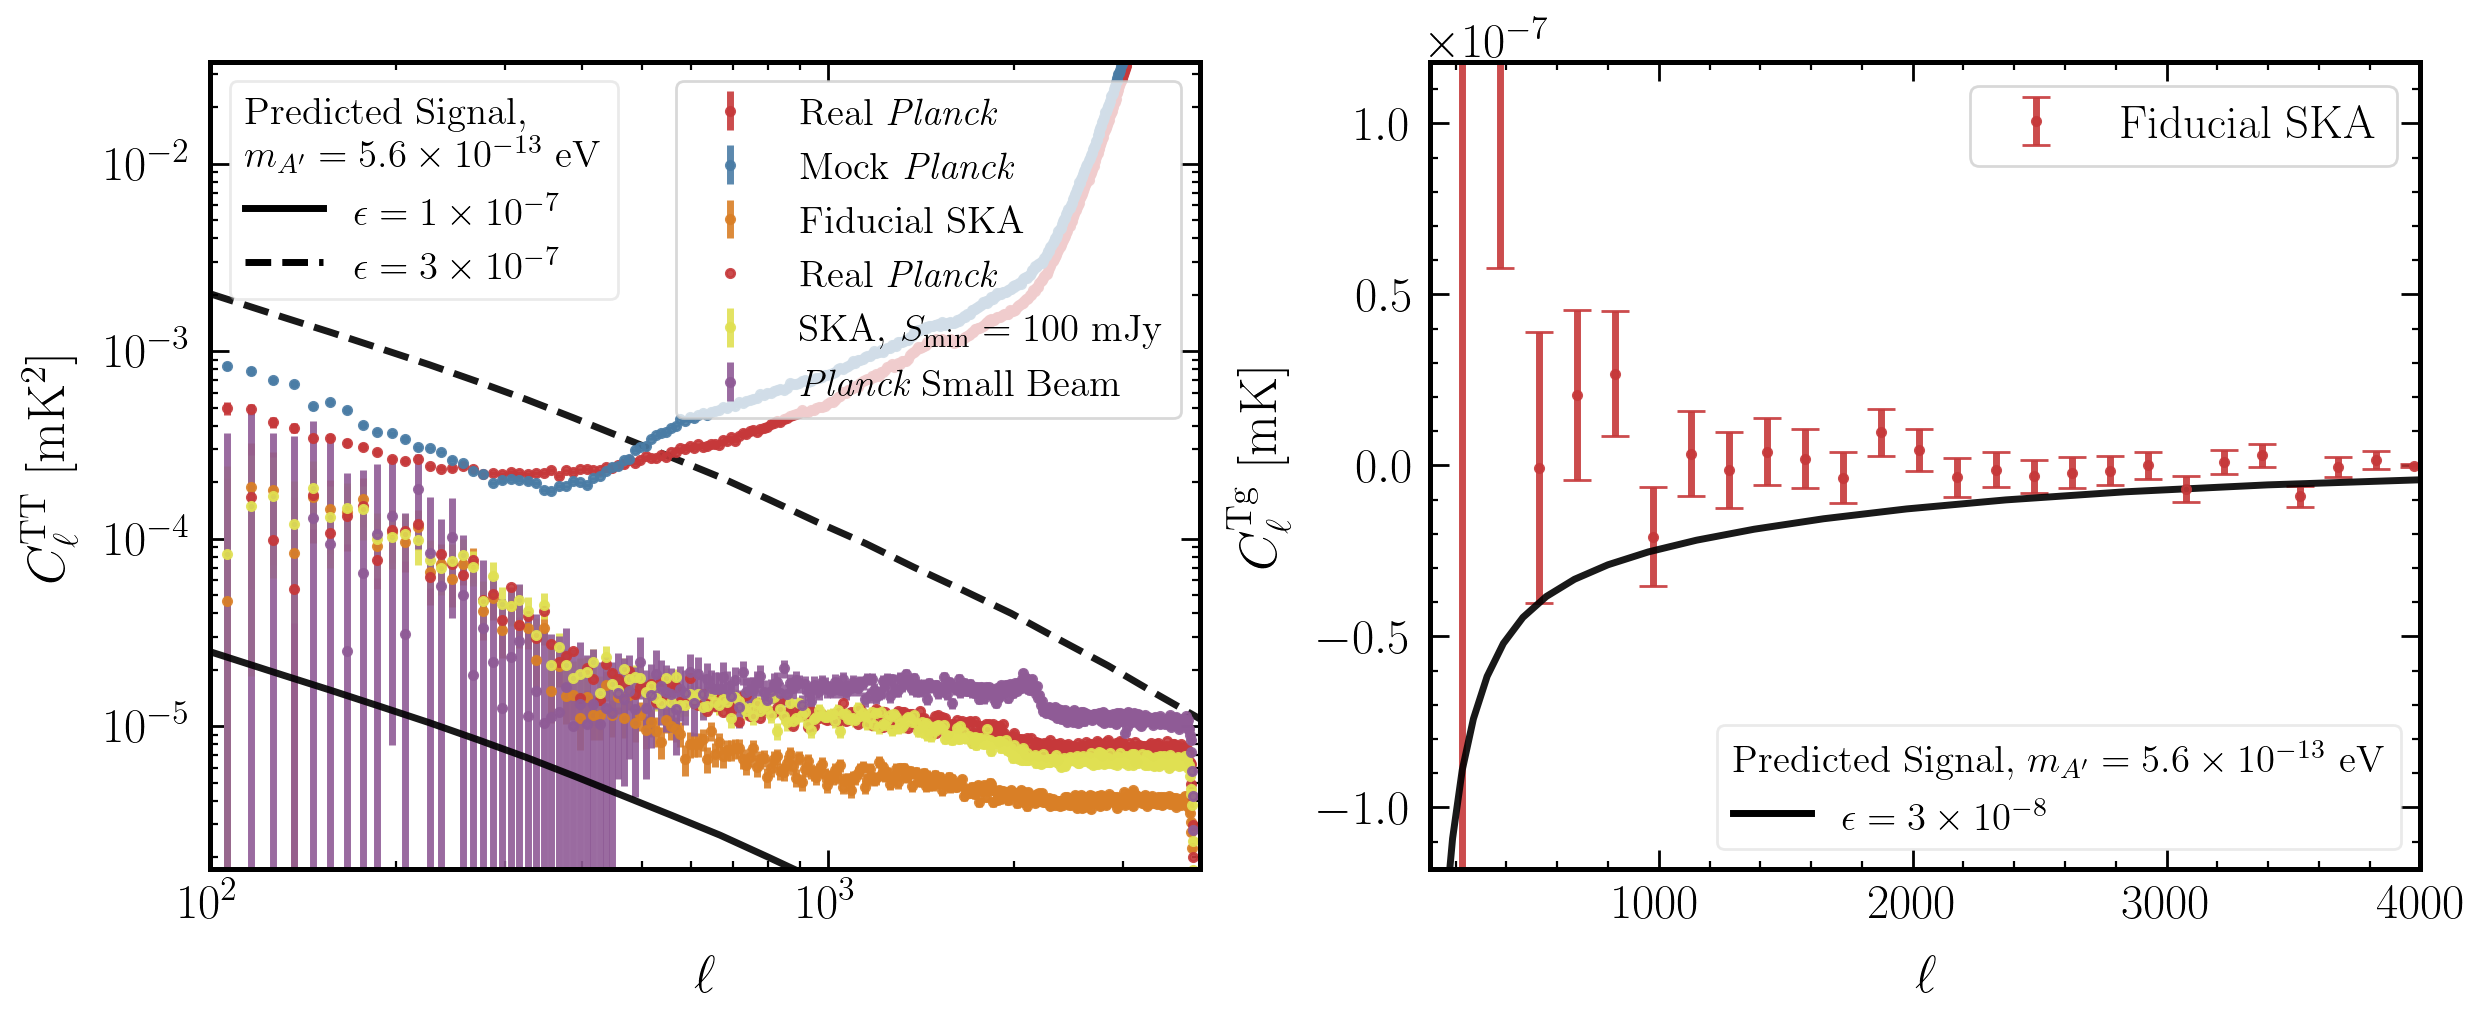

In [13]:
from matplotlib.lines import lineStyles

fig, ax = plt.subplots(1, 2, figsize=(2*6.153846153846153, 5.0), constrained_layout=True)


ax[0].errorbar(
    binning.get_effective_ells(),
    mccarthy_Cls * mc_prefac**2 / new_prefac**2 ,
    yerr=mc_prefac**2 * np.sqrt(np.diag(mccarthy_covs)) / new_prefac**2,
    capsize=0,
    linestyle=" ",
    marker=".",
    label=r"Real \textit{Planck}",
    color=cols_default[0],
)
ax[0].errorbar(
    binning.get_effective_ells(),
    mock_planck_Cls * mc_prefac**2 / new_prefac**2,
    yerr= mc_prefac**2 * np.sqrt(np.diag(mock_planck_covs)) / new_prefac**2,
    capsize=0,
    linestyle=" ",
    marker=".",
    label=r"Mock \textit{Planck}",
    color=cols_default[1],
)
ax[0].errorbar(
    binning.get_effective_ells(),
    new_freq / new_prefac**2,
    yerr=np.sqrt(np.diag(new_freq_covs)) / new_prefac**2,
    capsize=0,
    linestyle=" ",
    marker=".",
    label="Fiducial SKA",
    color=cols_default[4],
)
ax[0].errorbar(
    nmt.NmtBin.from_nside_linear(2048, 10).get_effective_ells(),
    new_Cls / new_prefac**2 ,
    # yerr=mc_prefac**2 * np.sqrt(np.diag(mccarthy_covs)) / new_prefac**2,
    capsize=0,
    linestyle=" ",
    marker=".",
    label=r"Real \textit{Planck}",
    color=cols_default[0],
)
ax[0].errorbar(
    binning.get_effective_ells(),
    new_freq_big_pt_src / new_prefac**2,
    yerr=np.sqrt(np.diag(new_freq_big_pt_src_covs)) / new_prefac**2,
    capsize=0,
    linestyle=" ",
    marker=".",
    label=r"SKA, $S_{\rm min}=100$ mJy",
    color=cols_default[5],
)
ax[0].errorbar(
    binning.get_effective_ells(),
    small_beam / new_prefac**2,
    yerr=np.sqrt(np.diag(small_beam_covs)) / new_prefac**2,
    capsize=0,
    linestyle=" ",
    marker=".",
    label=r"$\textit{Planck}$ Small Beam",
    color=cols_default[3],
)
ax[0].plot(
    signal_ls,
    (2.73e3) ** 2 * (1e-7)**4 * signal / new_prefac**2,
    linestyle="-",
    color="k",
    # label="Theoretical Signal",
)
ax[0].plot(
    signal_ls,
    (2.73e3) ** 2 * (3e-7)**4 * signal / new_prefac**2,
    linestyle="--",
    color="k",
    # label="Theoretical Signal",
)
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xlim(100, 4000)
ax[0].set_ylim(0.5e-17 / new_prefac**2, 1e-13 / new_prefac**2)

small_eps_line = Line2D([0,1],[0,1],linestyle='-', color='k')
big_eps_line = Line2D([0,1],[0,1],linestyle='--', color='k')
legend2 = ax[0].legend([small_eps_line, big_eps_line], [r"$\epsilon=1\times10^{-7}$", r"$\epsilon=3\times10^{-7}$"], 
                     fontsize=14, loc="upper left", frameon=True, 
                     title="Predicted Signal,\n" + r"$m_{A'}=5.6\times 10^{-13}$ eV",
                     title_fontsize=14)

# legend2.set_title("Predicted Signal,\n" + r"$m_{A'}=5.6\times 10^{-13}$ eV")
ax[0].add_artist(legend2)
legend2._legend_box.align = 'left'
    
legend1 = ax[0].legend(fontsize=14, frameon=True, loc="upper right", framealpha=0.75) # loc='center left', bbox_to_anchor=(1, 0.5))

ax[0].set_xlabel(r"$\ell$")
ax[0].set_ylabel(r"$C^{\rm TT}_\ell$ [mK$^2$]")


ax[1].errorbar(
    cross_binning.get_effective_ells(),
    new_freq_cross / new_prefac,
    yerr=np.sqrt(np.diag(new_freq_cross_covs)) / new_prefac,
    # capsize=0,
    linestyle=" ",
    marker=".",
    label="Fiducial SKA",
    color=cols_default[0],
)

ax[1].plot(
    signal_ls,
    -(2.73e3) * (3e-8)**2 * cross_signal /new_prefac,
    linestyle="-",
    color="k",
    # label="Theoretical Signal",
)

legend2 = ax[1].legend([small_eps_line], [r"$\epsilon=3\times 10^{-8}$"], 
                     loc="lower right", frameon=True, 
                     title=r"Predicted Signal, $m_{A'}=5.6\times 10^{-13}$ eV", 
                     title_fontsize=14, fontsize=14)

ax[1].add_artist(legend2)
legend2._legend_box.align = 'left'

legend1 = ax[1].legend(frameon=True, loc="upper right", framealpha=0.75) # loc='center left', bbox_to_anchor=(1, 0.5))

# ax[1].set_xscale("log")
ax[1].set_xlim(100, 4000)
ax[1].set_ylim(-0.2e-12/new_prefac,  0.2e-12/new_prefac)

ax[1].set_xlabel(r"$\ell$")
ax[1].set_ylabel(r"$C^{\rm Tg}_\ell$ [mK]")
ax[1].ticklabel_format(axis='y', style='sci', scilimits=(-4, 4))
# plt.savefig("plots/prd_Cl_comparsion.pdf", bbox_inches="tight")

# plt.xlabel(r"$\ell$")
# plt.ylabel(r"$C^{\rm TT}_\ell$ [mK$^2$]")
# plt.savefig("plots/mccarthy_comparison.pdf", bbox_inches="tight")